# Clustering the Polar Bears II


El clustering con AvgLatitude, AvgLongitude, TotalDistance es a nivel de individuo y puede revelar **grupos geográficos o patrones migratorios globales**.

Clustering por individuo (ubicación y distancia total)

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from warnings import filterwarnings

filterwarnings('ignore')


In [2]:
sns.set_style("white") 
sns.set_palette("pastel")
plt.rcParams.update({
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.figsize": (8, 4),
    "axes.edgecolor": "0.8",
})


## Load data

In [3]:
# Load the data into a pandas dataframe
df = pd.read_parquet("../data/processed/feature_dataset.parquet")
df.head()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,...,season,x_proj,y_proj,prev_se_x,prev_se_y,bearing,prev_bearing,bearing_change,distance_per_day_real,movement_pattern
0,1,1986-07-01 18:00:00,69.7730,-141.3960,5835,5835,69.772693,-141.403451,NaN,NaN,...,verano,-2.199487e+06,246846.113968,NaN,NaN,NaN,NaN,0.000000,1.560623,estacionario
1,1,1986-07-02 00:00:00,69.7738,-141.3834,2517,2517,69.773429,-141.388987,69.772693,-141.403451,...,verano,-2.199467e+06,246281.720783,5835.0,5835.0,154.841241,NaN,0.000000,7.640792,estacionario
2,1,1986-07-02 06:00:00,69.7736,-141.3448,5323,5323,69.764930,-141.331186,69.773429,-141.388987,...,verano,-2.200658e+06,244167.346190,2517.0,2517.0,148.477694,154.841241,6.363548,7.640792,estacionario
3,1,1986-07-02 12:00:00,69.7727,-141.2902,8840,8840,69.783728,-141.265125,69.764930,-141.331186,...,verano,-2.198852e+06,241400.844917,5323.0,5323.0,176.425859,148.477694,27.948165,7.640792,estacionario
4,1,1986-07-02 18:00:00,69.7717,-141.2289,11637,11637,69.778055,-141.296034,69.783728,-141.265125,...,verano,-2.199351e+06,242656.504996,8840.0,8840.0,157.258475,176.425859,19.167384,7.640792,estacionario


In [4]:
# df[df.UniqueAnimalID == 311]

In [5]:
df.shape

(294215, 38)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294215 entries, 0 to 294214
Data columns (total 38 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   UniqueAnimalID         294215 non-null  int64         
 1   timestamp              294215 non-null  datetime64[ns]
 2   mu_lat                 294215 non-null  float64       
 3   mu_lon                 294215 non-null  float64       
 4   se_mu_x                294215 non-null  int64         
 5   se_mu_y                294215 non-null  int64         
 6   adj_lat                294215 non-null  float64       
 7   adj_lon                294215 non-null  float64       
 8   prev_lat               293822 non-null  float64       
 9   prev_lon               293822 non-null  float64       
 10  prev_time              294215 non-null  datetime64[ns]
 11  distance_km            294215 non-null  float64       
 12  time_diff_hr           294215 non-null  floa

In [7]:
df.describe()

,UniqueAnimalID,timestamp,mu_lat,mu_lon,se_mu_x,se_mu_y,adj_lat,adj_lon,prev_lat,prev_lon,...,AvgLongitude,Year,x_proj,y_proj,prev_se_x,prev_se_y,bearing,prev_bearing,bearing_change,distance_per_day_real
count,294215.000000,294215,294215.000000,294215.000000,294215.000000,294215.000000,294215.000000,294215.000000,293822.000000,293822.000000,...,294215.000000,294215.000000,2.942150e+05,2.942150e+05,293822.000000,293822.000000,293822.000000,293430.000000,294215.000000,294215.000000
mean,252.595775,2001-02-27 04:01:01.644715648,72.299086,-154.581870,10321.019826,10321.019826,72.299071,-154.581750,72.300323,-154.572981,...,-154.580750,1999.506235,-1.767268e+06,6.286931e+05,10324.541260,10324.541260,180.048586,180.047414,22.297008,21.775596
min,1.000000,1985-07-01 18:00:00,65.071000,-179.999900,11.000000,11.000000,65.073795,-180.185209,65.073795,-180.185209,...,-179.969657,1985.000000,-2.320601e+06,-5.805984e+05,11.000000,11.000000,91.329054,91.329054,0.000000,0.011927
25%,108.000000,1992-07-23 00:00:00,70.847200,-166.173500,2752.000000,2752.000000,70.846895,-166.173693,70.848102,-166.150305,...,-166.017760,1991.000000,-1.995308e+06,3.221916e+05,2755.250000,2755.250000,166.637254,166.634545,8.872394,12.687108
50%,279.000000,2002-08-31 12:00:00,71.880400,-152.410900,8651.000000,8651.000000,71.879940,-152.410637,71.881608,-152.401962,...,-151.297349,2000.000000,-1.791045e+06,5.641188e+05,8656.000000,8656.000000,180.045761,180.045122,18.868532,19.211106
75%,361.000000,2008-11-06 18:00:00,73.444200,-144.126050,15501.500000,15501.500000,73.443720,-144.126218,73.444619,-144.123211,...,-144.960464,2008.000000,-1.556768e+06,9.394948e+05,15506.000000,15506.000000,193.452939,193.452069,32.192824,27.650653
max,541.000000,2017-11-30 18:00:00,79.999700,-111.104300,66766.000000,66766.000000,80.012180,-111.104288,80.012180,-111.104288,...,-124.503721,2017.000000,-7.767790e+05,1.645228e+06,66766.000000,66766.000000,270.530592,270.530592,129.575422,382.404926
std,151.705725,NaN,2.083701,14.039252,8853.029487,8853.029487,2.083780,14.039521,2.083033,14.035177,...,12.617263,9.136306,2.751749e+05,4.415760e+05,8852.805603,8852.805603,19.775328,19.776176,16.843698,15.187460


In [8]:
df.nunique()

UniqueAnimalID              393
timestamp                 18963
mu_lat                    81231
mu_lon                   214324
se_mu_x                   34931
se_mu_y                   34931
adj_lat                  294215
adj_lon                  294215
prev_lat                 293822
prev_lon                 293822
prev_time                 18962
distance_km              293968
time_diff_hr                206
velocity_kmh             294213
prev_velocity            294215
acceleration_kmph2       294215
date                       4743
daylight_hours           198051
is_polar_night                2
is_midnight_sun               2
min                          67
max                         176
dias_tracking               140
TotalDistance_km            393
distance_per_day            393
AvgLatitude                 393
AvgLongitude                393
Year                         30
season                        3
x_proj                   294215
y_proj                   294215
prev_se_

In [9]:
# 1. Agrupar por osa
df_individuos = df.groupby("UniqueAnimalID").agg({
    "AvgLatitude": "first",
    "AvgLongitude": "first",
    "TotalDistance_km": "first"
}).reset_index()

df_individuos.rename(columns={"TotalDistance_km": "TotalDistance"}, inplace=True)

### Normalizar datos

In [10]:
scaler_ind = StandardScaler()
X_ind = scaler_ind.fit_transform(df_individuos[["AvgLatitude", "AvgLongitude", "TotalDistance"]])


### Nube de puntos antes del clustering

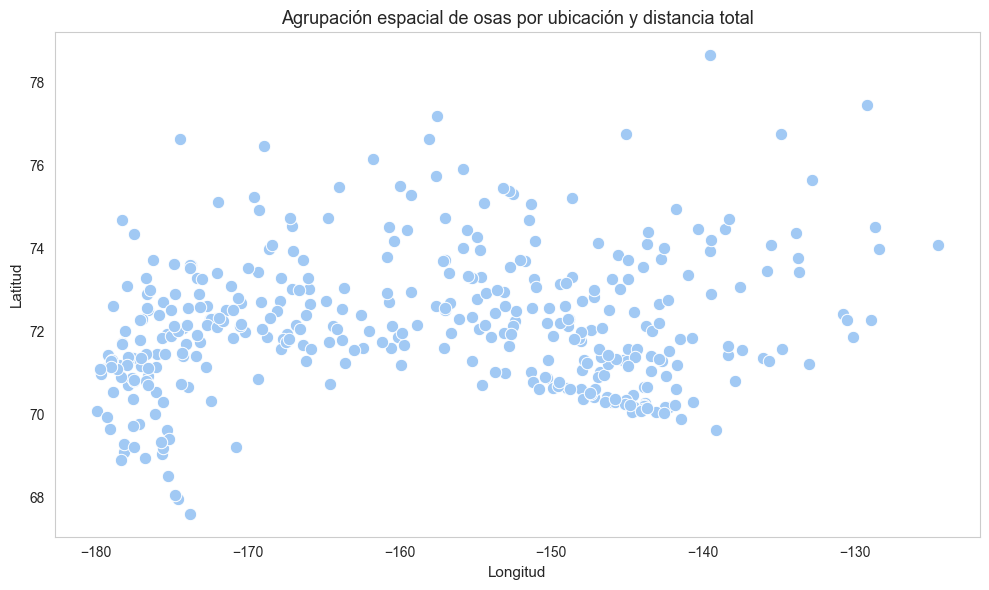

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_individuos,
    x="AvgLongitude",
    y="AvgLatitude",
    palette="Set2",
    s=80
)
plt.title("Agrupación espacial de osas por ubicación y distancia total")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show();

### Evaluación de diferentes valores de k (método del codo y silhouette)

In [12]:

# 3. Método del codo para elegir k
inertias = []
# silhouettes = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10)
    labels = kmeans.fit_predict(X_ind)
    inertias.append(kmeans.inertia_)
    # silhouettes.append(silhouette_score(X_ind, labels))


### Visualizar métricas

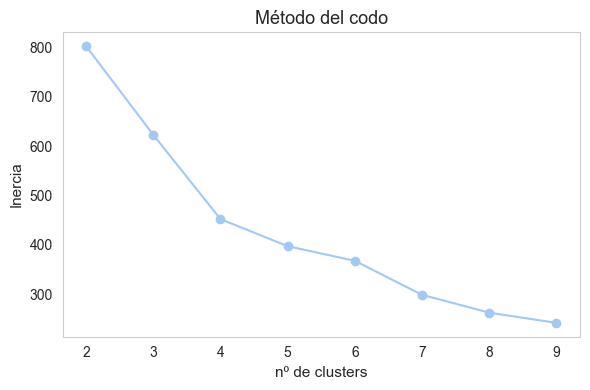

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, marker='o')
plt.title("Método del codo")
plt.xlabel("nº de clusters")
plt.ylabel("Inercia")
plt.tight_layout()
plt.show()


* k = 3 parece ser un buen compromiso entre simplicidad y segmentación útil.
* k = 5 según un artículo [A Journey Through the Arctic](https://medium.com/@viritaromero/a-journey-through-the-arctic-using-machine-learning-to-cluster-female-polar-bears-based-on-8a2870c5e53b)


* A partir de k = 5, las mejoras son marginales (la curva se aplana), lo que sugiere una sobresegmentación.

### _k_= 3

In [14]:
k_ind = 3 
kmeans_ind = KMeans(n_clusters=k_ind, random_state=10)
df_individuos["cluster"] = kmeans_ind.fit_predict(X_ind)


### Visualización

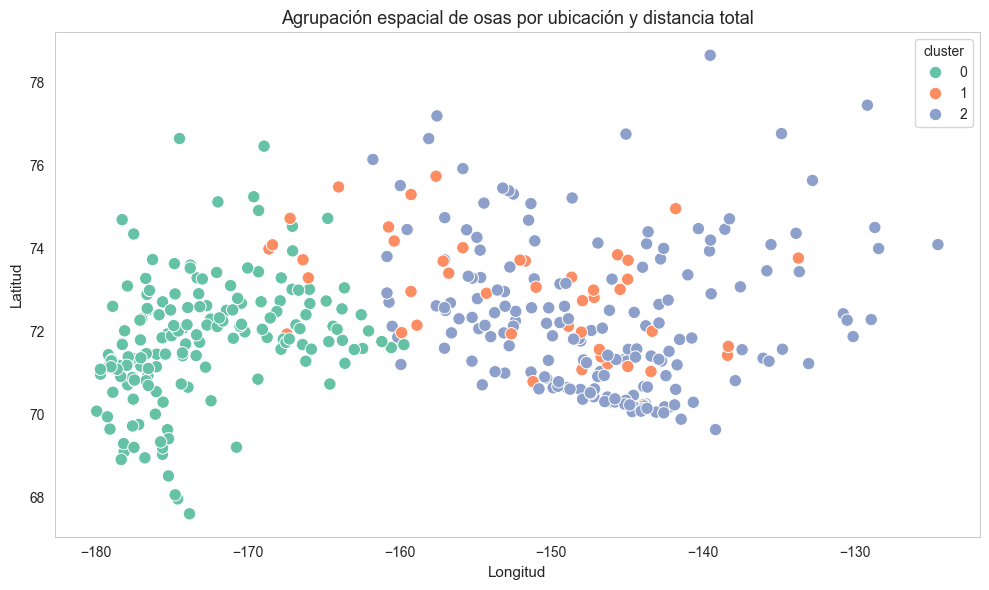

In [15]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_individuos,
    x="AvgLongitude",
    y="AvgLatitude",
    hue="cluster",
    palette="Set2",
    s=80
)
plt.title("Agrupación espacial de osas por ubicación y distancia total")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show();


### Análisis descriptivo por cluster

In [16]:
df_individuos.groupby("cluster")[["AvgLatitude", "AvgLongitude", "TotalDistance"]].describe()


AvgLatitude                                                        \
              count       mean       std        min        25%        50%   
cluster                                                                     
0             169.0  71.788110  1.469909  67.598268  71.104990  71.810644   
1              46.0  72.924718  1.331028  70.229621  71.942282  72.996527   
2             178.0  72.305536  1.792102  69.627802  70.874807  72.037043   

                              AvgLongitude              ...              \
               75%        max        count        mean  ...         75%   
cluster                                                 ...               
0        72.568323  76.640603        169.0 -172.903493  ... -169.292926   
1        73.750052  75.732897         46.0 -152.170101  ... -145.789111   
2        73.347988  78.646984        178.0 -146.860476  ... -142.682535   

                    TotalDistance                                          \
                max         count          mean          std          min   
cluster                                                                     
0       -159.717676         169.0   2515.358164  1535.268492    10.187866   
1       -133.706122          46.0  11276.119155  4686.016175  6697.730612   
2       -124.503721         178.0   3752.226054  1799.098499   306.526263   

                                                                
                 25%           50%           75%           max  
cluster                                                         
0        1292.621095   2351.297116   3357.545165   7792.733784  
1        8650.542310  10252.970164  12121.488190  34022.903720  
2        2553.921160   3362.015377   5193.319010   7943.693364  

[3 rows x 24 columns]

| Cluster | Descripción Geográfica                    | Latitud Media | Longitud Media | Distancia Total Media (km) | Nº de Osas |
| ------- | ----------------------------------------- | ------------- | -------------- | -------------------------- | ---------- |
| **0**   | Zona más occidental (Mar de Bering)       | 71.8          | -172.9         | 2,515                      | 169        |
| **1**   | Zona más oriental y norte, muy activas    | 72.9          | -152.2         | **11,276**                 | 46         |
| **2**   | Intermedia, más dispersas geográficamente | 72.3          | -146.9         | 3,752                      | 178        |


Interpretación

    Cluster 0: Osas mayoritariamente situadas al oeste, con desplazamientos moderados.

    Cluster 1: Osas altamente móviles y situadas más al norte y este; posiblemente con comportamiento migratorio más marcado.

    Cluster 2: Osas con movilidad intermedia, repartidas en zonas algo más centrales.

### _k_= 5

In [17]:
k_ind = 5
kmeans_ind = KMeans(n_clusters=k_ind, random_state=10)
df_individuos["cluster"] = kmeans_ind.fit_predict(X_ind)


### Visualización

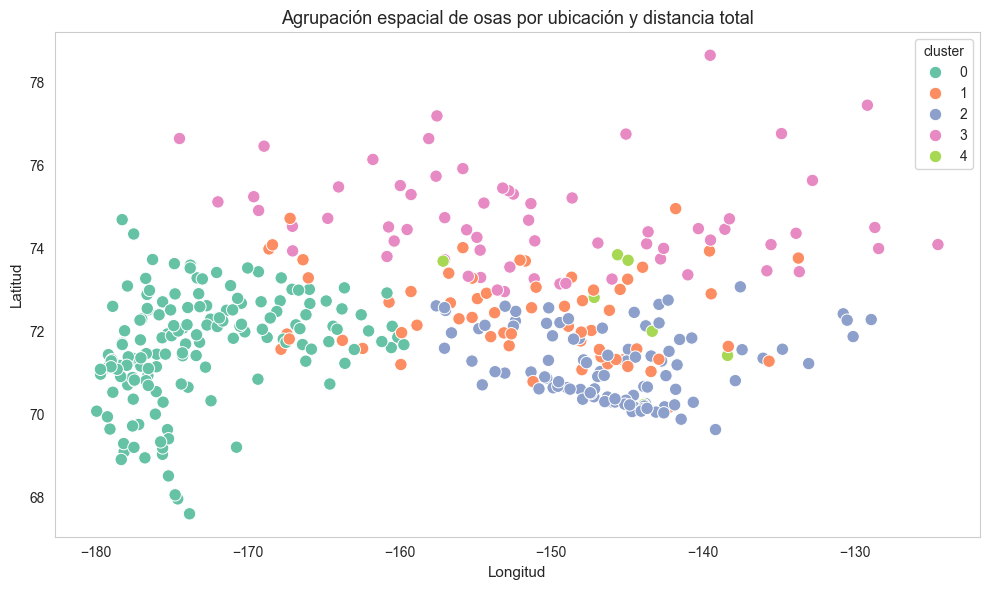

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_individuos,
    x="AvgLongitude",
    y="AvgLatitude",
    hue="cluster",
    palette="Set2",
    s=80
)
plt.title("Agrupación espacial de osas por ubicación y distancia total")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.tight_layout()
plt.show();


### Análisis descriptivo por cluster

In [19]:
df_individuos.groupby("cluster")[["AvgLatitude", "AvgLongitude", "TotalDistance"]].describe()


AvgLatitude                                                        \
              count       mean       std        min        25%        50%   
cluster                                                                     
0             160.0  71.630086  1.282644  67.598268  71.080574  71.797172   
1              63.0  72.418175  1.024844  70.166068  71.607494  72.297072   
2              99.0  71.160758  0.855144  69.627802  70.389972  71.014540   
3              64.0  74.708648  1.201003  72.952083  73.946672  74.462193   
4               7.0  72.526524  1.374544  70.229621  71.705619  72.811936   

                              AvgLongitude              ...              \
               75%        max        count        mean  ...         75%   
cluster                                                 ...               
0        72.510891  74.685675        160.0 -173.047774  ... -170.156978   
1        73.154394  74.952044         63.0 -151.937983  ... -145.947535   
2        71.877639  73.067391         99.0 -145.799189  ... -142.806904   
3        75.322358  78.646984         64.0 -150.739750  ... -142.191445   
4        73.696583  73.839704          7.0 -145.782755  ... -143.621830   

                    TotalDistance                                           \
                max         count          mean          std           min   
cluster                                                                      
0       -159.717676         160.0   2394.976126  1377.168164     10.187866   
1       -133.706122          63.0   8455.485241  2113.000622   5151.823466   
2       -128.903161          99.0   3038.779519  1519.224396    306.526263   
3       -124.503721          64.0   4016.368162  1782.017770   1203.263162   
4       -138.375098           7.0  19702.109054  6963.904925  14176.127235   

                                                                 
                  25%           50%           75%           max  
cluster                                                          
0         1274.921818   2292.678912   3299.626408   6297.976054  
1         6920.289514   7922.499775  10252.970164  12717.109430  
2         2088.989509   2973.534580   3859.163404   6456.900376  
3         2878.257355   3501.434210   5083.337228  10198.546163  
4        14898.555712  18633.115968  20642.752514  34022.903720  

[5 rows x 24 columns]

Perfecto, ¡vamos a ponerle “nombre y apellido” a cada cluster geográfico! Esto ayuda muchísimo en presentaciones para hacer la narrativa más comprensible y memorable. Usaremos los valores medios de **latitud** y **distancia total** para caracterizarlos.

---

###  Cluster summary simplificado

| Cluster | AvgLatitude | TotalDistance (km) | Nº osas | Posible nombre          |
| ------- | ----------- | ------------------ | ------- | ----------------------- |
| 0       | \~71.6      | \~2,395            | 160     | **Residencial central** |
| 1       | \~72.4      | \~8,455            | 63      | **Migradora este**      |
| 2       | \~71.2      | \~3,039            | 99      | **Costera Chukchi**     |
| 3       | \~74.7      | \~4,016            | 64      | **Zona norte/extrema**  |
| 4       | \~72.5      | \~19,702 (!)       | 7       | **Altamente móviles**   |

---

### Propuestas de nombres por cluster:

1. **Cluster 0 – Residencial central**

   * Zona media (latitud \~71.6), con desplazamientos moderados. Muchas osas → patrón común.

2. **Cluster 1 – Migradora este**

   * Latitud ligeramente más alta (\~72.4), pero gran distancia → indicios de migración larga.

3. **Cluster 2 – Costera Chukchi**

   * Más al sur (\~71.1) y menor desplazamiento. Podría reflejar un hábitat más restringido.

4. **Cluster 3 – Zona norte/extrema**

   * Latitud más alta (\~74.7) → osas en zonas más polares. Menor número pero interesante.

5. **Cluster 4 – Altamente móviles**

   * ¡Casi 20,000 km! Pocas osas pero gran movilidad. Podrían ser outliers o migradoras extremas.

---

### ¿Qué hacer ahora?

* Añadir una nueva columna `cluster_geo_label` con estos nombres.
* Usarla en visualizaciones, mapas o tablas para mejorar la legibilidad.



### Guardar resultado con cluster asignado


In [ ]:
df_individuos.to_parquet("../dat/models/df_clusterizado_geo.parquet", index=False)
